In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import math

# Use the best available device: CUDA (NVIDIA) > MPS (Apple Silicon) > CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

# Fix random seeds for reproducibility across all backends
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(42)

# ── Constants ──────────────────────────────────────────────────────────────────

# Per-channel mean and std computed from the CIFAR-10 training set,
# used to normalise pixel values to zero mean and unit variance
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

BATCH_SIZE  = 128  # Number of images processed per gradient update
NUM_WORKERS = 2    # Parallel CPU processes used to prefetch data

# ── Transforms ────────────────────────────────────────────────────────────────

# RandAugment applies a random pair of augmentation policies (e.g. shear,
# rotate, posterise) at magnitude 9; fall back to identity if unavailable
try:
    _randaug = T.RandAugment(num_ops=2, magnitude=9)
except AttributeError:
    _randaug = T.Lambda(lambda img: img)

# Training pipeline: aggressive augmentation to improve generalisation
#   RandomCrop       — shifts the image by up to 4 pixels in any direction
#   RandomHorizontalFlip — mirrors ~50 % of images left-right
#   ToTensor         — converts PIL image (0-255) to float tensor (0-1)
#   Normalize        — centres each channel using CIFAR-10 statistics
#   RandomErasing    — randomly masks out a small rectangle to prevent
#                      the model from relying on any single region
train_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3), value='random'),
])

# Test pipeline: no augmentation — only normalise so evaluation is deterministic
test_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# ── Data loaders ──────────────────────────────────────────────────────────────

# Download CIFAR-10 (if not already cached) and apply the transforms above
train_ds = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_tf)
test_ds  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf)

# pin_memory=True speeds up CPU→GPU transfers by keeping tensors in page-locked memory
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# ── Model ─────────────────────────────────────────────────────────────────────

class IntermediateBlock(nn.Module):
    """
    Multi-branch convolutional block with a learned soft gate.

    Creates L independent conv branches with different receptive fields:
      - 3×3  (standard local features)
      - 5×5  (slightly wider context)
      - 3×3 dilated=2  (wider context without extra parameters)

    A global average pool feeds a small linear layer whose softmax output
    weights each branch's contribution, letting the network learn which
    kernel size matters most for each spatial location.
    """
    def __init__(self, c_in, c_out, L=3,
                 kernel_sizes=(3, 5, 3),
                 paddings=(1, 2, 2),
                 dilations=(1, 1, 2)):
        super().__init__()
        self.L = L

        # Build one Conv→BN→ReLU branch per (kernel, padding, dilation) triple
        self.convs = nn.ModuleList()
        for k, p, d in zip(kernel_sizes, paddings, dilations):
            self.convs.append(nn.Sequential(
                nn.Conv2d(c_in, c_out, kernel_size=k, padding=p, dilation=d),
                nn.BatchNorm2d(c_out),
                nn.ReLU(inplace=True),
            ))

        # Gate: maps spatially-pooled input features to L branch weights
        self.gate_fc = nn.Linear(c_in, L)

    def forward(self, x):
        # Global average pool → (B, c_in), then linear → softmax → (B, L) weights
        a = self.gate_fc(x.mean(dim=(2, 3))).softmax(dim=1)

        # Run all branches in parallel and stack to (B, L, c_out, H, W)
        stacked = torch.stack([conv(x) for conv in self.convs], dim=1)

        # Broadcast gate weights over spatial dims and compute weighted sum
        return (stacked * a.view(a.size(0), a.size(1), 1, 1, 1)).sum(dim=1)


class OutputBlock(nn.Module):
    """
    Classification head: global average pool → two-layer MLP → class logits.

    Collapsing spatial dimensions with average pooling before the MLP keeps
    the parameter count low while still allowing the network to combine
    features from across the full feature map.
    """
    def __init__(self, c_in, num_classes=10, hidden=256, dropout=0.3):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(c_in, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),        # Dropout reduces co-adaptation of neurons
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        # Average-pool spatial dims to get a (B, c_in) feature vector
        return self.mlp(x.mean(dim=(2, 3)))


class CIFARNetWide(nn.Module):
    """
    Three-stage wide variant of CIFARNet.

    Channel progression: 3 → 96 → 192 → 384
    Spatial progression: 32×32 → 16×16 → 8×8 → 4×4 (via MaxPool after each block)
    The wider channels give the model more representational capacity than the
    base 64/128/256 version.
    """
    def __init__(self, num_classes=10, mlp_hidden=384, dropout=0.3):
        super().__init__()
        self.b1   = IntermediateBlock(3,   96,  L=3)   # 32×32 → 96 channels
        self.b2   = IntermediateBlock(96,  192, L=3)   # 16×16 → 192 channels
        self.b3   = IntermediateBlock(192, 384, L=3)   # 8×8   → 384 channels
        self.pool = nn.MaxPool2d(2)                     # halves spatial resolution
        self.out  = OutputBlock(384, num_classes=num_classes, hidden=mlp_hidden, dropout=dropout)

    def forward(self, x):
        x = self.pool(self.b1(x))   # 32→16
        x = self.pool(self.b2(x))   # 16→8
        x = self.pool(self.b3(x))   # 8→4
        return self.out(x)

# ── Training helpers ──────────────────────────────────────────────────────────

def accuracy(logits, y):
    """Returns the number of correct predictions in a batch (not the fraction)."""
    return (logits.argmax(dim=1) == y).float().sum().item()


def train_one_epoch(model, loader, criterion, optimizer, device, grad_clip_norm=None):
    """
    Runs a single full pass over the training set.

    Returns average loss per sample and average accuracy over the epoch.
    grad_clip_norm, if set, caps the global gradient norm to prevent
    large weight updates that can destabilise training.
    """
    model.train()
    total_loss, total_correct, n = 0.0, 0, 0
    _batch_losses = []

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()           # Clear gradients from previous batch

        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()                 # Compute gradients via backprop

        if grad_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)

        optimizer.step()                # Update weights

        _batch_losses.append(loss.item())   # record per-batch loss

        # Accumulate weighted totals for epoch-level averages
        total_loss    += loss.item() * X.size(0)
        total_correct += accuracy(logits, y)
        n             += X.size(0)

    return total_loss / n, total_correct / n, _batch_losses


def evaluate(model, loader, criterion, device):
    """
    Evaluates the model on a held-out loader (no gradient tracking).

    model.eval() disables dropout and switches BatchNorm to use its running
    statistics rather than batch statistics, giving deterministic outputs.
    """
    model.eval()
    total_loss, total_correct, n = 0.0, 0, 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            total_loss    += criterion(logits, y).item() * X.size(0)
            total_correct += accuracy(logits, y)
            n             += X.size(0)

    return total_loss / n, total_correct / n

# ── Experiment runner ─────────────────────────────────────────────────────────

def run_experiment(exp_name, model_builder, train_loader, test_loader,
                   num_epochs=120, lr=0.1, momentum=0.9, weight_decay=5e-4,
                   label_smoothing=0.0, warmup_epochs=0, eta_min=0.0,
                   grad_clip_norm=None):
    """
    Builds, trains and evaluates a model, then returns the best checkpoint.

    Optimiser:  SGD with Nesterov momentum — generally outperforms Adam on
                CIFAR when paired with a cosine schedule.
    Scheduler:  Linear warmup for `warmup_epochs`, then cosine annealing
                down to `eta_min`. Warmup avoids large, noisy updates at the
                start when weights are poorly initialised.
    Criterion:  CrossEntropyLoss with label smoothing, which softens the
                one-hot targets and acts as a regulariser.
    """
    model     = model_builder().to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum,
                                weight_decay=weight_decay, nesterov=True)

    def lr_lambda(epoch):
        # Linear ramp from 0 → lr over the first warmup_epochs
        if warmup_epochs > 0 and epoch < warmup_epochs:
            return float(epoch + 1) / float(warmup_epochs)
        # Cosine decay from lr → eta_min for the remaining epochs
        progress   = float(epoch - warmup_epochs) / float(max(1, num_epochs - warmup_epochs))
        cosine     = 0.5 * (1.0 + math.cos(math.pi * progress))
        min_factor = (eta_min / lr) if lr > 0 else 0.0
        return min_factor + (1.0 - min_factor) * cosine

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    train_accs, test_accs         = [], []
    batch_losses                  = []
    best_test_acc, best_state     = 0.0, None

    for epoch in range(num_epochs):
        train_loss, train_acc, _bl = train_one_epoch(
            model, train_loader, criterion, optimizer, device, grad_clip_norm
        )
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        train_accs.append(train_acc)
        batch_losses.extend(_bl)
        test_accs.append(test_acc)
        scheduler.step()    # Advance the LR schedule after each epoch

        # Snapshot the weights whenever we hit a new best test accuracy
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # Print progress at epoch 1 and every 10 epochs thereafter
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"[{exp_name}] Epoch {epoch+1}/{num_epochs}  "
                  f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  "
                  f"test_loss={test_loss:.4f}  test_acc={test_acc:.4f}")

    # Restore the best checkpoint before returning
    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    print(f"[{exp_name}] Best test accuracy: {best_test_acc:.4f}")
    return {'name': exp_name, 'model': model, 'best_test_acc': best_test_acc,
            'train_accs': train_accs, 'test_accs': test_accs,
            'batch_losses': batch_losses}

# ── Run ───────────────────────────────────────────────────────────────────────

# Train the wide model with:
#   - strong data augmentation (RandomErasing pipeline defined above)
#   - 10-epoch linear LR warmup followed by cosine annealing over 150 epochs
#   - label smoothing of 0.1 to regularise the classifier
result = run_experiment(
    exp_name        = 'wide_strong_ls010',
    model_builder   = CIFARNetWide,
    train_loader    = train_loader,
    test_loader     = test_loader,
    warmup_epochs   = 10,
    num_epochs      = 150,
    lr              = 0.1,
    weight_decay    = 5e-4,
    label_smoothing = 0.10,
)

Device: cuda


100%|██████████| 170M/170M [00:05<00:00, 34.1MB/s] 


[wide_strong_ls010] Epoch 1/150  train_loss=1.7777  train_acc=0.3965  test_loss=1.6993  test_acc=0.4611
[wide_strong_ls010] Epoch 10/150  train_loss=1.1128  train_acc=0.7421  test_loss=1.1555  test_acc=0.7221
[wide_strong_ls010] Epoch 20/150  train_loss=0.9973  train_acc=0.7945  test_loss=1.1391  test_acc=0.7210
[wide_strong_ls010] Epoch 30/150  train_loss=0.9632  train_acc=0.8120  test_loss=1.0385  test_acc=0.7696
[wide_strong_ls010] Epoch 40/150  train_loss=0.9447  train_acc=0.8197  test_loss=1.0789  test_acc=0.7594
[wide_strong_ls010] Epoch 50/150  train_loss=0.9254  train_acc=0.8301  test_loss=1.1064  test_acc=0.7453
[wide_strong_ls010] Epoch 60/150  train_loss=0.9063  train_acc=0.8387  test_loss=0.9864  test_acc=0.7954
[wide_strong_ls010] Epoch 70/150  train_loss=0.8818  train_acc=0.8490  test_loss=1.2070  test_acc=0.7088
[wide_strong_ls010] Epoch 80/150  train_loss=0.8542  train_acc=0.8644  test_loss=1.0529  test_acc=0.7738
[wide_strong_ls010] Epoch 90/150  train_loss=0.8254  tra

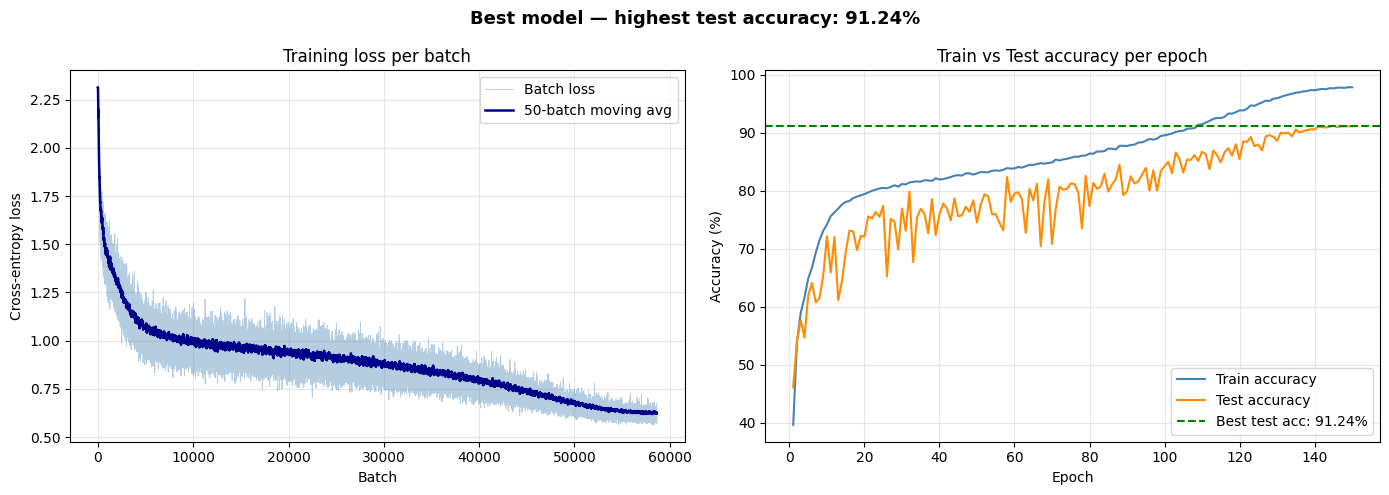

Highest test accuracy: 91.24%


In [2]:
import matplotlib.pyplot as plt

batch_losses = result['batch_losses']
train_accs   = result['train_accs']
test_accs    = result['test_accs']
best_acc     = result['best_test_acc']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: loss per training batch ───────────────────────────────────────
ax = axes[0]
ax.plot(batch_losses, linewidth=0.6, alpha=0.4, color='steelblue', label='Batch loss')

# Smooth with a rolling average so the trend is clearly visible
window = 50
if len(batch_losses) >= window:
    smoothed = [sum(batch_losses[max(0, i-window):i+1]) / min(i+1, window)
                for i in range(len(batch_losses))]
    ax.plot(smoothed, linewidth=1.8, color='darkblue', label=f'{window}-batch moving avg')

ax.set_xlabel('Batch')
ax.set_ylabel('Cross-entropy loss')
ax.set_title('Training loss per batch')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 2: train / test accuracy per epoch ───────────────────────────────
ax = axes[1]
epochs = range(1, len(train_accs) + 1)
ax.plot(epochs, [a * 100 for a in train_accs], label='Train accuracy', color='steelblue')
ax.plot(epochs, [a * 100 for a in test_accs],  label='Test accuracy',  color='darkorange')
ax.axhline(best_acc * 100, color='green', linestyle='--',
           label=f'Best test acc: {best_acc*100:.2f}%')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Train vs Test accuracy per epoch')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f"Best model — highest test accuracy: {best_acc*100:.2f}%", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('best_model_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Highest test accuracy: {best_acc*100:.2f}%')
